# QASM Simulator using Qiskit  

## Introduction

The QASM simulator models quantum measurements by executing a circuit multiple times and recording the outcomes.  
Unlike the Statevector simulator, which provides direct access tot he quantum state, the QASM simulator only provides measurement results, similiar to real quantum hardware.  

Objectives:  

- Understand quantum measurements

- Remember the concept of shots.

- Observe probabilistic outcomes.  

- Compare theoretical and experimental results.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from matplotlib import pyplot as plt

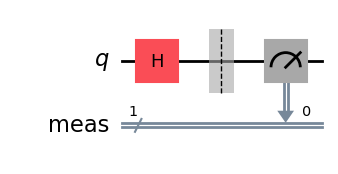

In [2]:
qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()
qc.draw('mpl')


we created the Hadamard gate, which has an equal superposition of 0⟩ and |1⟩  
After measurement the qubit collapses into one of these basis states:
    $$|\psi\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$


In [ ]:
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit, shots=1000).result()
counts = result.get_counts()
print(counts)

{'0': 527, '1': 473}


AreSimulator executes quantum circuit on  classical computer and mimics the behavior of a quantum computer. It allows us to test and debug quantum circuits without needing access to actual quantum hardware.  

Transpiling a quantum circuit is the process of optimizing and transforming it to be compatible with a specific quantum hardware or simulator. It involves rearranging gates, reducing gate counts, and ensuring that the circuit can be executed efficiently on the target platform.  

A shot represents one execution of the quantum circuit.
since measurement is probabilistic, a single execution provuides only one outcome.  
By repeating the experiment many times, we can estimate the probability distribution.


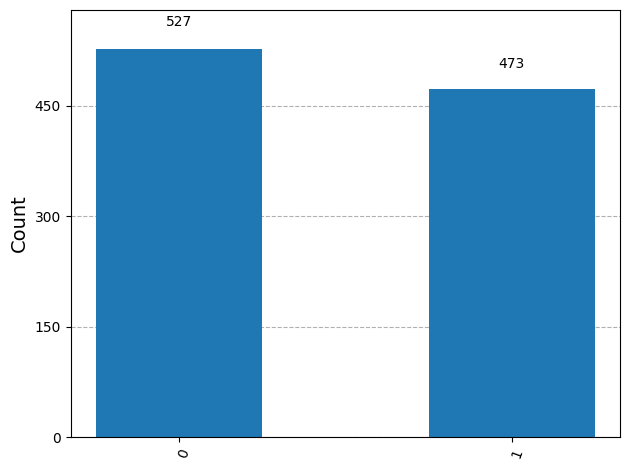

In [9]:
plot_histogram(counts)


## Results

Roughly equal bar  
Only small statistical fluctuations.


In [10]:
#Expriment with different number of shots
for shots in [10, 100, 1000, 10000]:
    
    result = simulator.run(
        compiled_circuit,
        shots=shots
    ).result()

    counts = result.get_counts()

    print(f"Shots = {shots}")
    print(counts)

Shots = 10
{'1': 4, '0': 6}
Shots = 100
{'1': 60, '0': 40}
Shots = 1000
{'0': 496, '1': 504}
Shots = 10000
{'0': 4940, '1': 5060}


## Observation table


| Shots | Outcome Example |
| ----- | --------------- |
| 10    | 4 / 3           |
| 100   | 60 / 40         |
| 1000  | 496 / 504       |
| 10000 | 4940 / 5060     |


## Explanations

As the number of shots increases, the observed frequencies become closer to the theoretical probabilities.

This demonstrates the statistical nature of quantum measurement.

## Statevector vs QASM
Statevector simulator:  

- provides amplitude
- Gives exact probabilities
- No measurement required

QASM Simulator:

- Provides measurement counts
- Approximate Probabilities experimentally
- Mimics real quantum hardware

## Conclusion

# Conclusion

The QASM simulator was used to study quantum measurements through repeated circuit execution.

Key findings:

- Quantum measurements are probabilistic.
- A single measurement does not reveal the complete quantum state.
- Multiple shots are required to estimate probabilities.
- Experimental results converge toward theoretical predictions as the number of shots increases.
- The QASM simulator provides a realistic representation of how quantum computers are observed in practice.
- Quantum mechanics predicts probability distributions, not individual outcomes.



This notebook bridges the gap between ideal quantum states and real quantum experiments, providing the foundation for statistical analysis, noise studies, and quantum hardware execution.
